In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [11]:
df = pd.read_csv("agriculture_yield_dataset.csv")

In [12]:
#Q1 Dataset Overview
# Number of rows and columns
print("Shape of the dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# First 10 records
print("\nFirst 10 rows:")
print(df.head(10))

Shape of the dataset: (1500, 8)

Columns:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 rows:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8

In [13]:
#Q2 Data Types and Missing Values
# Data types
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Columns having missing values
missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with missing values:")
print(missing_cols.tolist())


rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with missing values:
[]


In [14]:
#Q3 Descriptive Statistics
stats = df.describe()
print(stats)

# Highest mean
highest_mean = stats.loc['mean'].idxmax()
print("Highest mean feature:", highest_mean)

# Highest standard deviation
highest_std = stats.loc['std'].idxmax()
print("Highest std feature:", highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [15]:
#Q4 Distribution Analysis
!pip install plotly matplotlib seaborn --quiet

In [3]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

In [12]:
fig=px.histogram(df,x='rainfall_mm',marginal='box',nbins=47,title='Distribution of rainfall')
fig.update_layout(bargap=0.1)
fig.show()


In [ ]:
#observations:-
#the median is 761.2 mm
#the minimum is 300.2 mm
#the maximum is 1200 mm

In [15]:
fig=px.histogram(df,x='temperature_c',marginal='box',nbins=47,title='Distribution of Temperature')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
#observations:-
#the median is 27.7 C
#the minimum is 18 C
#the maximum is 38 C

In [17]:
fig=px.histogram(df,x='fertilizer_kg',marginal='box',nbins=47,title='Distribution of Fertilizer')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
#observations:-
#the median is 146.8 kg
#the minimum is 50.3kg
#the maximum in 249.9 kg

In [19]:
fig=px.histogram(df,x='yield_ton_per_hectare',marginal='box',nbins=47,title='Distribution of yield per hectare')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
#observations:-
#the median is 5.01 yield per hectare
#the minimum is 2.09 yield per hectare
#the maximum in 7.86 yield per hectare

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


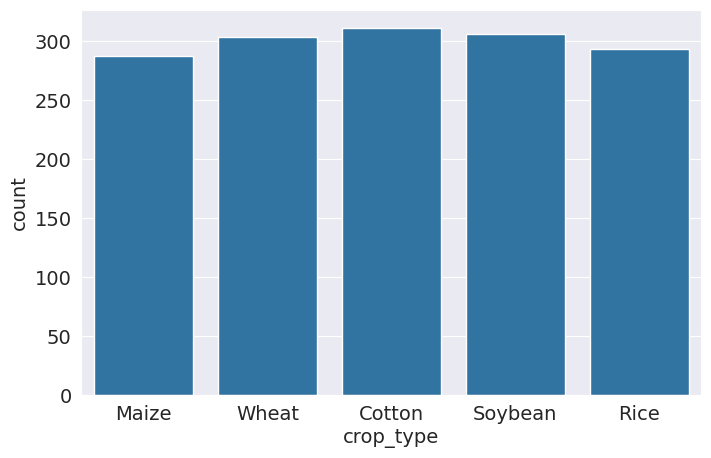

Most frequent crop: Cotton


In [21]:
#Q5 Crop Type Analysis

print(df['crop_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.show()

most_crop = df['crop_type'].mode()[0]
print("Most frequent crop:", most_crop)

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


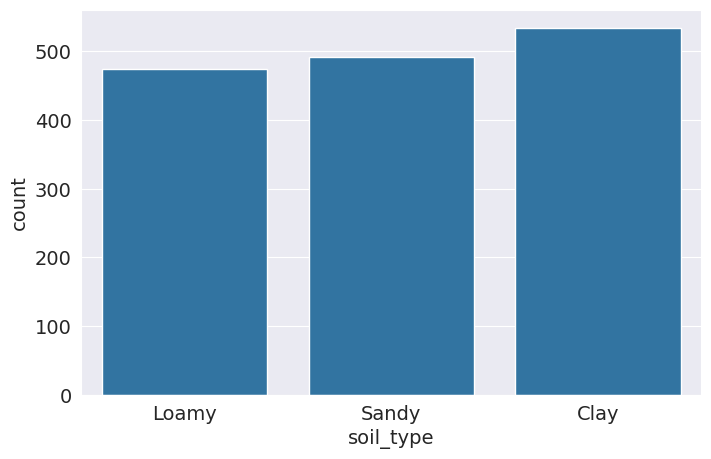

Most common soil type: Clay


In [22]:
#Q6 Soil Type Analysis

print(df['soil_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.show()

most_soil = df['soil_type'].mode()[0]
print("Most common soil type:", most_soil)

In [23]:
#Q7 Yield Distribution
fig=px.histogram(df,x='yield_ton_per_hectare',marginal='box',nbins=47,title='Distribution of yield per hectare')
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
#the distribution is approximately a normal/bell curve
#the outlier values are 2.09,2.21 and 7.86

In [25]:
#Q8 Scatter Plot Analysis
fig=px.scatter(df,
               x='rainfall_mm',
               y='yield_ton_per_hectare',
               opacity=0.8,
               title='Rainfall vs Yield')
fig.update_traces(marker_size=5)
fig.show()
fig=px.scatter(df,
               x='fertilizer_kg',
               y='yield_ton_per_hectare',
               opacity=0.8,
               title='Fertilizer vs Yield')
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
#rainfall has a stronger relationship with yield

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

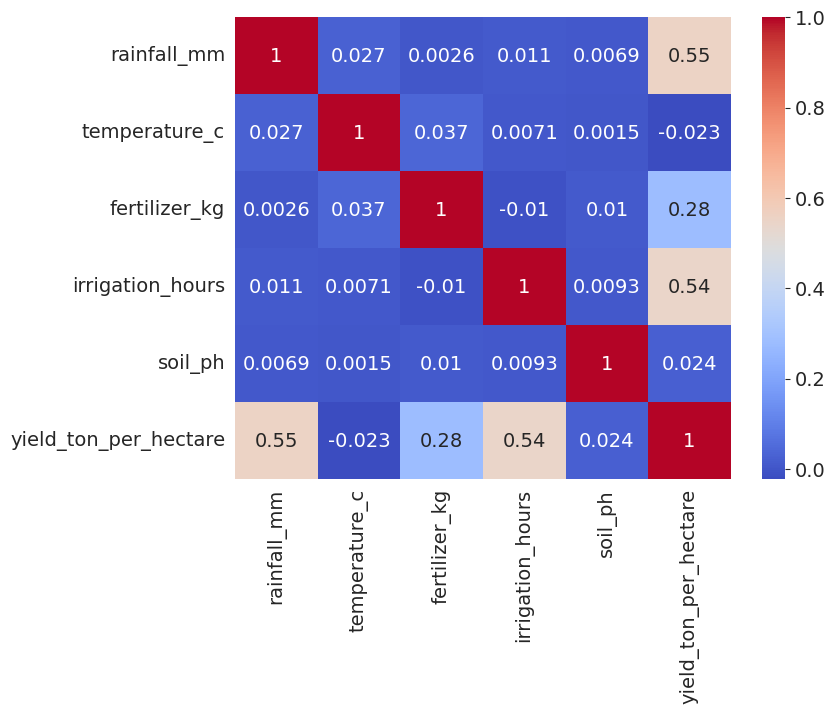

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64

Top correlated features:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [27]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

#top 3 features correlated with yield
yield_corr = corr['yield_ton_per_hectare'].sort_values(ascending=False)

print(yield_corr)
print("\nTop correlated features:")
print(yield_corr[1:4])   # to exclude yield itself

In [29]:
#Q10 Group-Based Analysis
crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_avg)

best_crop = crop_avg.idxmax()
print("Highest yielding crop:", best_crop)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Highest yielding crop: Rice


In [30]:
soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_avg)

best_soil = soil_avg.idxmax()
print("Highest yielding soil:", best_soil)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest yielding soil: Loamy


In [31]:
#Q11 Feature Encoding
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)
#one hot encoding
df_encoded = pd.get_dummies(df,
                            columns=cat_cols,
                            drop_first=True)

print(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat

In [32]:
#Q12 Feature Selection
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Target variable: yield_ton_per_hectare")
print("X shape:", X.shape)
print("y shape:", y.shape)

Target variable: yield_ton_per_hectare
X shape: (1500, 11)
y shape: (1500,)


In [33]:
#Q13 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [34]:
#Q14 Linear Regression Model
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Intercept:")
print(lr.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print(coef_df)

Intercept:
1.587132027736121
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933


In [35]:
highest_coef = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(highest_coef.head(1))

          Feature  Coefficient
6  crop_type_Rice     0.863993
